### Входные переменные:
* Температура (T): низкая, средняя, высокая
* Влажность (H): низкая, средняя, высокая
* Уровень CO2 (C): низкий, средний, высокий
* Уровень шума (N): низкий, средний, высокий \
### Выходная переменная:
* Коэффицент комфорта: неудовлетворительный, удовлетворительный, хороший
-----------------------

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations, chain

### Продукционные правила

In [2]:
rules = [
    (["температура низкая", "влажность низкая"], "комфорт неудовлетворительный"),
    (["температура низкая" , "влажность средняя"], "комфорт неудовлетворительный"),
    (["температура низкая" , "влажность высокая"], "комфорт неудовлетворительный"),
    (["температура средняя" , "влажность низкая"], "комфорт удовлетворительный"),
    (["температура средняя", "влажность средняя"], "комфорт хороший"),
    (["температура средняя", "влажность высокая"], "комфорт удовлетворительный"),
    (["температура высокая", "влажность низкая"], "комфорт хороший"),
    (["температура высокая", "влажность средняя"], "комфорт удовлетворительный"),
    (["температура высокая", "влажность высокая"], "комфорт неудовлетворительный"),
    (["уровень CO2 низкий", "уровень шума низкий"], "комфорт хороший"),
    (["уровень CO2 низкий", "уровень шума средний"], "комфорт удовлетворительный"),
    (["уровень CO2 низкий", "уровень шума высокий"], "комфорт удовлетворительный"),
    (["уровень CO2 средний", "уровень шума низкий"], "комфорт удовлетворительный"),
    (["уровень CO2 средний", "уровень шума средний"], "комфорт неудовлетворительный"),
    (["уровень CO2 средний", "уровень шума высокий"], "комфорт неудовлетворительный"),
    (["уровень CO2 высокий", "уровень шума низкий"], "комфорт неудовлетворительный"),
    (["уровень CO2 высокий", "уровень шума средний"], "комфорт неудовлетворительный"),
    (["уровень CO2 высокий", "уровень шума высокий"], "комфорт неудовлетворительный"),
    (["температура высокая", "уровень CO2 высокий"], "комфорт неудовлетворительный"),
    (["температура низкая", "уровень CO2 высокий"], "комфорт неудовлетворительный"),
    (["влажность высокая", "уровень CO2 высокий"], "комфорт неудовлетворительный"),
    (["уровень шума высокий", "уровень CO2 высокий"], "комфорт неудовлетворительный"),
    (["температура средняя", "уровень CO2 низкий"], "комфорт хороший"),
    (["влажность средняя", "уровень CO2 низкий"], "комфорт хороший"),
    (["уровень шума средний", "уровень CO2 низкий"], "комфорт хороший"),
    (["температура высокая", "уровень шума низкий"], "комфорт хороший"),
    (["температура низкая", "уровень шума низкий"], "комфорт удовлетворительный"),
    (["влажность низкая", "уровень шума высокий"], "комфорт неудовлетворительный"),
    (["влажность высокая", "уровень шума средний"], "комфорт неудовлетворительный"),
    
    (["температура высокая", "влажность средняя", "уровень CO2 низкий"], "комфорт хороший"),
    (["температура низкая", "влажность высокая", "уровень CO2 низкий"], "комфорт удовлетворительный"),
    (["температура средняя", "влажность высокая", "уровень CO2 низкий"], "комфорт удовлетворительный"),
    (["уровень CO2 низкий", "уровень шума высокий", "влажность высокая"], "комфорт неудовлетворительный"),
    (["уровень CO2 средний", "уровень шума высокий", "температура высокая"], "комфорт неудовлетворительный"),
    (["уровень CO2 высокий", "уровень шума низкий", "температура низкая"], "комфорт неудовлетворительный"),
    (["температура высокая", "уровень CO2 средний", "влажность низкая"], "комфорт хороший"),
    (["температура высокая", "уровень CO2 средний", "влажность средняя"], "комфорт удовлетворительный"),
    (["температура низкая", "уровень CO2 средний", "влажность высокая"], "комфорт неудовлетворительный"),
    (["температура средняя", "уровень CO2 высокий", "влажность низкая"], "комфорт неудовлетворительный"),
    (["уровень шума низкий", "влажность средняя", "уровень CO2 низкий"], "комфорт хороший"),
    (["уровень шума средний", "влажность высокая", "уровень CO2 средний"], "комфорт неудовлетворительный"),
    (["уровень шума высокий", "влажность низкая", "уровень CO2 высокий"], "комфорт неудовлетворительный"),
    (["температура высокая", "уровень шума средний", "уровень CO2 низкий"], "комфорт хороший"),
    
    (["температура средняя", "уровень шума средний", "уровень CO2 низкий","влажность средняя"], "комфорт удовлетворительный"),
    (["температура высокая", "уровень шума средний", "уровень CO2 низкий","влажность высокая"], "комфорт неудовлетворительный"),
    (["температура высокая", "уровень шума средний", "уровень CO2 высокий","влажность высокая"], "комфорт неудовлетворительный"),
    (["температура низкая", "уровень шума высокий", "уровень CO2 низкий","влажность высокая"], "комфорт неудовлетворительный"),
    (["температура средняя", "уровень шума высокий", "уровень CO2 высокий","влажность высокая"], "комфорт неудовлетворительный"),
    (["температура средняя", "уровень шума низкий", "уровень CO2 средний","влажность средняя"], "комфорт хороший"),
    (["температура низкая", "уровень шума низкий", "уровень CO2 средний","влажность средняя"], "комфорт удовлетворительный"),
    (["температура низкая", "уровень шума высокий", "уровень CO2 высокий","влажность высокая"], "комфорт неудовлетворительный"),
]

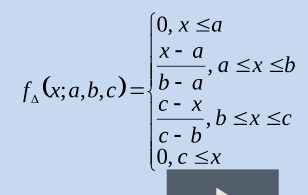

In [3]:
class Model:
    def __init__(self, rules):
        self.rules = rules
        self.temp = (
            'температура ',
                     {
            "низкая": [0, 0, 20],
            "средняя": [15, 25, 35],
            "высокая": [30, 40, 40]
        })
        
        self.damp = (
            'влажность ',
                     {
            "низкая": [0, 0, 30],
            "средняя": [20, 50, 80],
            "высокая": [70, 100, 100]
        })
        
        self.CO2 = (
            "уровень CO2 ",
                    {
            "низкий": [0, 0, 400],
            "средний": [300, 600, 900],
            "высокий": [800, 1000, 1000]
        })
        
        self.level_noise = (
            "уровень шума ",
                    {
            "низкий": [0, 0, 50],
            "средний": [40, 70, 100],
            "высокий": [90, 100, 100]
        })
        
        self.comfort = (
            "комфорт",
                    {
            "неудовлетворительный": [0,0,60],
            "удовлетворительный": [20,70,100],
            "хороший": [40,100,100],
        })

    
    def print(self):
        for i,item in enumerate(rules):
            print(f"Правило {i+1}: {" И ".join(item[0])} -> {item[1]}")


    def print_input_vars(self):
        fig, axs = plt.subplots(5,1, figsize=(8, 16))
        for i, variable in enumerate([self.temp, self.damp, self.CO2, self.level_noise, self.comfort]):
            name_var, var = variable
            var_functions = [k[1] for k in var.items()]
            var_name_result = [k[0] for k in var.items()]
            for j in range(3):
                linespace = np.array([var_functions[0][0], var_functions[j][0],var_functions[j][1],
                                      var_functions[j][2],var_functions[2][2]])
                #axs[i].scatter(30, 1) точка
                y = np.array([0,0,1,0,0])
                axs[i].plot(linespace, y, label=var_name_result[j])
                axs[i].set_ylabel(name_var)
                axs[i].grid()
                axs[i].legend()
            
    def add_rule(self, rule_if, rule_then):
        for rif in rule_if.split(" ИЛИ "):
            rules.append((rif, rule_then))
            
    
    def check_warnings(self):
        rules = self.rules
        def issublist(lst1,lst2):
            for i in lst2:
                if i not in lst1:
                    return False
            return True
        for i, item1 in enumerate(rules):
            for j, item2 in enumerate(rules):
                rule1 = item1[0]
                rule2 = item2[0]
                if (issublist(rule1, rule2) or issublist(rule2,rule1)) and item1[1] == item2[1]  and i>j:
                    print(f"{i+1} -> {rule1} -> {item1[1]}")
                    print(f"{j+1} -> {rule2} -> {item2[1]}")
                    print("Избыточность!\n")
                if item1[1] != item2[1] and rule1==rule2 and i<j:
                    print(f"{i+1} -> {rule1} -> {item1[1]}")
                    print(f"{j+1} -> {rule2} -> {item2[1]}")
                    print("Противоречивость!\n")
        print('____________________________')
        def print_cycle(cycle, rules):
            def find_rule_if(rule_then, rules):
                for i in rules:
                    if i[1]==rule_then:
                        return i
                return ["NO","NO"]
            def find_rule_then(rule_if, rules):
                for i in rules:
                    if i[0][0]==rule_if:
                        return i
                return ["NO","NO"]
            print([find_rule_if(cycle[0], rules)[0][0]]+cycle+[find_rule_then(cycle[-1],rules)[1]])
        def check_cyclices(rules):
            def check(rule, rules, cycle, first_rule):
                for i in rules:
                    if rule[1] == i[0][0]:
                        cycle.append(i[1])
                        if first_rule[0][0] in cycle:
                            print_cycle(cycle,rules)
                            return True
                        return check(i,rules,cycle, first_rule)
            for i in rules:
                if check(i,rules,[],i):
                    return True
            return False
        print("Циклы есть!" if check_cyclices(rules) else "Циклов нет!")


    
    def membership_func(self, triangle_func, x):
        a,b,c = triangle_func
        if x <= a or c <= x:
            return 0
        if x < b:
            return (x-a)/(b-a)
        
        return (c-x)/(c-b)

    
    def translate_value(self, parameter, value):
        parameter = list(parameter.items())
        if value >= parameter[2][1][2]:
            return (parameter[2][0],1)
            
        if value <= parameter[0][1][0]:
            return (parameter[0][0],1)
            
        result = [(x[0],self.membership_func(x[1], value)) for x in parameter]
        return max(result, key = lambda x: x[1])
        
    
    def request(self, temp = None, damp = None, CO2 = None, level_noise = None):
        request = {}
        for param in ((self.temp, temp), 
                      (self.damp, damp), 
                      (self.CO2, CO2), 
                      (self.level_noise, level_noise)):
            if not param[1] is None:
                print(param)
                request[param[0][0]] = self.translate_value(param[0][1], param[1])
        print(f"ФАЗЗИФИКАЦИЯ:\n{request}\n\n")
        
        def issublist(lst1,lst2):
            for i in lst2:
                if i not in lst1:
                    return False
            return True
            
        def all_combinations(lst):
            return list(chain.from_iterable(combinations(lst, r) for r in range(len(lst) + 1)))[::-1]
            
        response = {}
        print("АГРЕГАЦИЯ И АКТИВАЦИЯ")
        for req in all_combinations(request.keys()):
            r = [i+request[i][0] for i in req]
            
            for condition, result in self.rules:
                if issublist(r, condition):
                    if min(request[i][1] for i in req):
                        response[(" И ".join(condition), result)] = min(request[i][1] for i in req)
                        print(f"{list(f"{i}{request[i]}" for i in req)} =>\n \
                        => ({" И ".join(condition)} -> {result} : {response[" И ".join(condition), result]})\n")
                    
        if len(response.keys()) == 0:
            print("Ничего не найдено")
            return None

        def defazz(var_results):
            def get_val(triangle_func, x, max_val):
                a,b,c = triangle_func
                if x<=a or x>=c:
                    return 0
                if x < b:
                    return (x-a)/(b-a) if (x-a)/(b-a) < max_val else max_val
                return (c-x)/(c-b) if (c-x)/(c-b) < max_val else max_val
                
            i=1
            maxUonX = [0.0 for x in np.linspace(0,100,1000)]
            
            fig, axs = plt.subplots(2, 1, figsize=(8, 4))
            for i, variable in enumerate([self.comfort]):
                name_result = variable[0]
                for val, tr_func in variable[1].items():
                    for j in var_results:
                        if (j[0][1] == name_result+' '+val):
                            linespace = np.linspace(0,100,1000)
                            y = np.array([get_val(tr_func, x, j[1]) for x in linespace])
                            i+=1
                            axs[0].plot(linespace, y, label=f"Правило {i}")

                            for index, u in enumerate(maxUonX):
                                maxUonX[index] = max(u, get_val(tr_func, linespace[index], j[1]))
            axs[0].legend()
            axs[1].plot(np.linspace(0,100,1000), maxUonX)
            
            res_of_defazz = np.sum(np.linspace(0,100,1000) * maxUonX) / np.sum(maxUonX)
            index = np.argmin(np.abs(np.linspace(0,100,1000)-res_of_defazz))
            axs[1].scatter(res_of_defazz, maxUonX[index],color='red')
            return res_of_defazz
            
        result = list(response.items())
        result.sort(key = lambda x: x[1])
        result = result[::-1]
        print(f"АККУМУЛЯЦИЯ (ГРАФИК)")
        for i,item in enumerate(result):
            print(f"Правило {i+1}: {item[0][0]} -> {item[0][1]} ({item[1]})")
            
        defazz_result = defazz(result)
        print(f"\nДЕФАЗЗИФИКАЦИЯ(график и результат)")
        return defazz_result

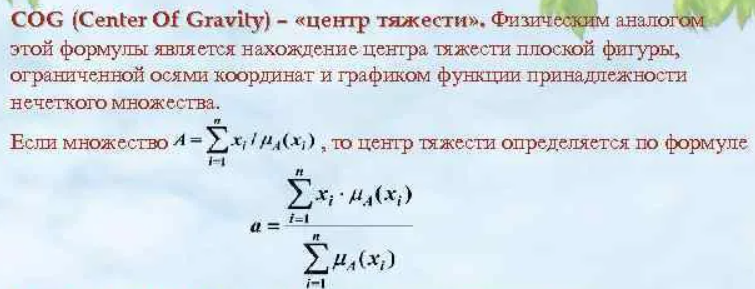

### (3) Выполнить анализ разработанной системы нечеткого вывода

In [6]:
model.print()

Правило 1: температура низкая И влажность низкая -> комфорт неудовлетворительный
Правило 2: температура низкая И влажность средняя -> комфорт неудовлетворительный
Правило 3: температура низкая И влажность высокая -> комфорт неудовлетворительный
Правило 4: температура средняя И влажность низкая -> комфорт удовлетворительный
Правило 5: температура средняя И влажность средняя -> комфорт хороший
Правило 6: температура средняя И влажность высокая -> комфорт удовлетворительный
Правило 7: температура высокая И влажность низкая -> комфорт хороший
Правило 8: температура высокая И влажность средняя -> комфорт удовлетворительный
Правило 9: температура высокая И влажность высокая -> комфорт неудовлетворительный
Правило 10: уровень CO2 низкий И уровень шума низкий -> комфорт хороший
Правило 11: уровень CO2 низкий И уровень шума средний -> комфорт удовлетворительный
Правило 12: уровень CO2 низкий И уровень шума высокий -> комфорт удовлетворительный
Правило 13: уровень CO2 средний И уровень шума низк

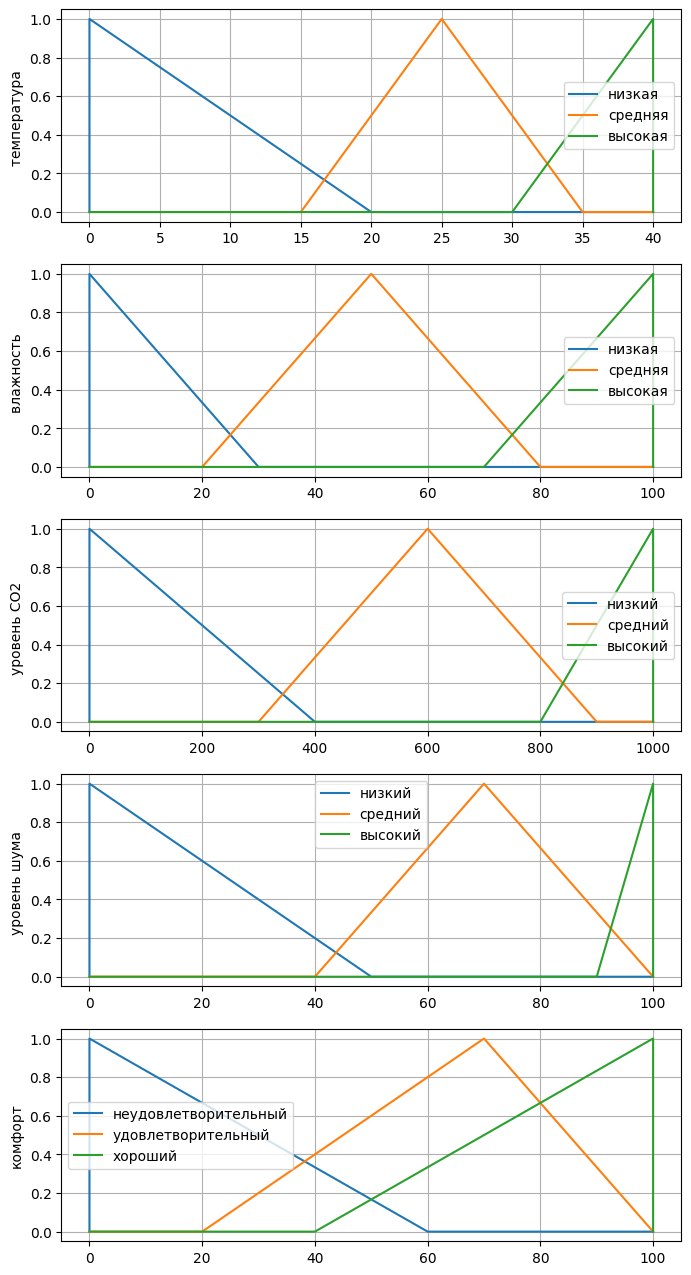

In [5]:
model = Model(rules)
model.print_input_vars()

(('температура ', {'низкая': [0, 0, 20], 'средняя': [15, 25, 35], 'высокая': [30, 40, 40]}), 50)
(('влажность ', {'низкая': [0, 0, 30], 'средняя': [20, 50, 80], 'высокая': [70, 100, 100]}), 20)
(('уровень CO2 ', {'низкий': [0, 0, 400], 'средний': [300, 600, 900], 'высокий': [800, 1000, 1000]}), 300)
(('уровень шума ', {'низкий': [0, 0, 50], 'средний': [40, 70, 100], 'высокий': [90, 100, 100]}), 45)
ФАЗЗИФИКАЦИЯ:
{'температура ': ('высокая', 1), 'влажность ': ('низкая', 0.3333333333333333), 'уровень CO2 ': ('низкий', 0.25), 'уровень шума ': ('средний', 0.16666666666666666)}


АГРЕГАЦИЯ И АКТИВАЦИЯ
["температура ('высокая', 1)", "влажность ('низкая', 0.3333333333333333)", "уровень CO2 ('низкий', 0.25)", "уровень шума ('средний', 0.16666666666666666)"] =>
                         => (температура высокая И влажность низкая -> комфорт хороший : 0.16666666666666666)

["температура ('высокая', 1)", "влажность ('низкая', 0.3333333333333333)", "уровень CO2 ('низкий', 0.25)", "уровень шума ('сре

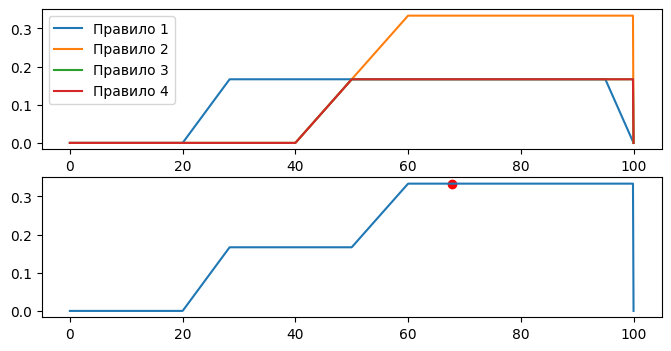

In [7]:
item = model.request(temp = 50, damp = 20, CO2=300, level_noise = 45)
    
print(f"Коэффицент комфорта равен: {item}")

(('температура ', {'низкая': [0, 0, 20], 'средняя': [15, 25, 35], 'высокая': [30, 40, 40]}), 25)
(('влажность ', {'низкая': [0, 0, 30], 'средняя': [20, 50, 80], 'высокая': [70, 100, 100]}), 50)
(('уровень CO2 ', {'низкий': [0, 0, 400], 'средний': [300, 600, 900], 'высокий': [800, 1000, 1000]}), 600)
(('уровень шума ', {'низкий': [0, 0, 50], 'средний': [40, 70, 100], 'высокий': [90, 100, 100]}), 0)
ФАЗЗИФИКАЦИЯ:
{'температура ': ('средняя', 1.0), 'влажность ': ('средняя', 1.0), 'уровень CO2 ': ('средний', 1.0), 'уровень шума ': ('низкий', 1)}


АГРЕГАЦИЯ И АКТИВАЦИЯ
["температура ('средняя', 1.0)", "влажность ('средняя', 1.0)", "уровень CO2 ('средний', 1.0)", "уровень шума ('низкий', 1)"] =>
                         => (температура средняя И влажность средняя -> комфорт хороший : 1.0)

["температура ('средняя', 1.0)", "влажность ('средняя', 1.0)", "уровень CO2 ('средний', 1.0)", "уровень шума ('низкий', 1)"] =>
                         => (уровень CO2 средний И уровень шума низкий -> ко

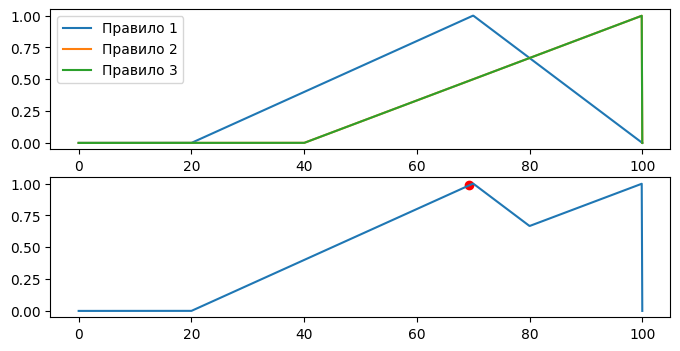

In [8]:
item = model.request(temp = 25, damp = 50, CO2=600, level_noise = 0)
    
print(f"Коэффицент комфорта равен: {item}")

(('температура ', {'низкая': [0, 0, 20], 'средняя': [15, 25, 35], 'высокая': [30, 40, 40]}), 25)
(('влажность ', {'низкая': [0, 0, 30], 'средняя': [20, 50, 80], 'высокая': [70, 100, 100]}), 50)
ФАЗЗИФИКАЦИЯ:
{'температура ': ('средняя', 1.0), 'влажность ': ('средняя', 1.0)}


АГРЕГАЦИЯ И АКТИВАЦИЯ
["температура ('средняя', 1.0)", "влажность ('средняя', 1.0)"] =>
                         => (температура средняя И влажность средняя -> комфорт хороший : 1.0)

АККУМУЛЯЦИЯ (ГРАФИК)
Правило 1: температура средняя И влажность средняя -> комфорт хороший (1.0)

ДЕФАЗЗИФИКАЦИЯ(график и результат)
Коэффицент комфорта равен: 79.96660655311291


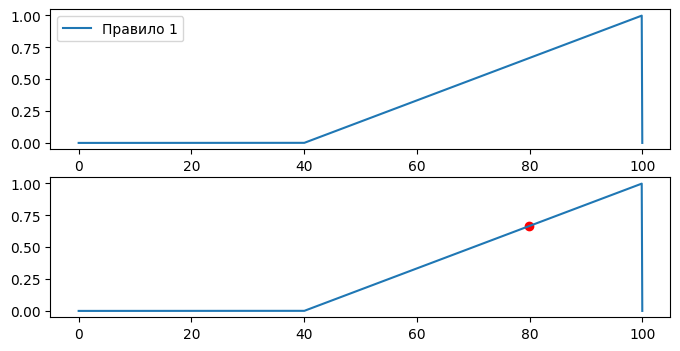

In [717]:
item = model.request(temp = 25, damp = 50)
    
print(f"Коэффицент комфорта равен: {item}")

In [718]:
item = model.request(temp = 20)
    
print(f"Коэффицент комфорта равен: {item}")

(('температура ', {'низкая': [0, 0, 20], 'средняя': [15, 25, 35], 'высокая': [30, 40, 40]}), 20)
ФАЗЗИФИКАЦИЯ:
{'температура ': ('средняя', 0.5)}


АГРЕГАЦИЯ И АКТИВАЦИЯ
Ничего не найдено
Коэффицент комфорта равен: None
